# Objectives

This notebook will showcase Tudatpy's capabilities to: 
1) Download IFMS files, SPICE kernels and Ancillary Data;
2) Simulate both Open and Closed Loop Doppler observables in a n-way configuration;
3) Experimental: converting Open-Loop Observables into "Equivalent" Closed-Loop observables.

We will choose **JUICE** as a test case. More specifically, we want to see what happened right before Earth's flyby in August 2024. 

## 1. Import Modules

First, we import all the necessary Python and `tudatpy` modules.

In [1]:
from tudatpy.interface import spice
from tudatpy.astro import time_representation, element_conversion
from tudatpy.astro.time_representation import DateTime
from datetime import datetime
from tudatpy.dynamics import environment_setup, environment
from tudatpy.estimation import observable_models_setup, observations_setup, observations
from tudatpy import estimation

import os
from tudatpy.math import interpolators
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import quad
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Helper Functions

We define two helper functions:
1.  `make_state_interpolator`: Creates a 6-state interpolator from time and state arrays.
2.  `compute_scipy_quadrature`: Performs numerical integration (quadrature) over a given time series. This is the core of converting open-loop (instantaneous) data to closed-loop (averaged) data.

In [2]:
def make_state_interpolator(times: np.ndarray, states: np.ndarray):
    interpolators = [interp1d(times, states[:, i], kind='linear', fill_value="extrapolate") for i in range(6)]

    def state_function(t: float) -> np.ndarray:
        return np.array([[f(t)] for f in interpolators])  # shape (6, 1)

    return state_function

def compute_scipy_quadrature(interpolated_function, times, integration_time=10):
    results = list()
    midpoints = list()

    a = min(times)
    max_time = max(times)

    while a + integration_time <= max_time:
        b = a + integration_time
        midpoint = (a + b) / 2
        result, _ = quad(interpolated_function, a, b)
        normalized_result = result / (b - a)
        results.append(normalized_result)
        midpoints.append(midpoint)
        a = b

    return results, midpoints

## 3. Simulation Setup

### Load SPICE Kernels

We (down)load the standard SPICE kernels plus mission-specific kernels for JUICE

In [3]:
from tudatpy.data.mission_data_downloader import *
object = LoadPDS()
spice.clear_kernels() #lets clear the kernels to avoid duplicates,since we will load all standard + Downloaded + existing kernels
start_date_juice = datetime(2024, 8, 5)
end_date_juice = datetime(2024, 8, 10)
kernel_files_juice, radio_science_files_juice, ancillary_files_juice = object.get_mission_files(
    input_mission = 'juice',
    start_date = start_date_juice,
    end_date = end_date_juice)
print(f'Total number of loaded kernels: {spice.get_total_count_of_kernels_loaded()}')

# Load Required Spice Kernels
spice.load_standard_kernels()
spice.load_kernel("juice_archive/ck/juice_sc_crema_5_1_150lb_23_1_baseline_v03.bc")
#spice.load_kernel("juice_archive/ck/juice_sc_meas_240801_240820_s240802_v04.bc")

======================================= Downloading JUICE Data ==============================================

=========================================== Folder(s) Creation ==================================================
Folder: juice_archive/ already exists and will not be overwritten.

Download JUICE Clock Files:
File: juice_archive/sclk/juice_fict_160326_v02.tsc already exists in: juice_archive/ and will not be downloaded.
File: juice_archive/sclk/juice_step_251014_v01.tsc already exists in: juice_archive/ and will not be downloaded.
Download JUICE Frame Files:
File: juice_archive/fk/juice_dsk_surfaces_v11.tf already exists in: juice_archive/ and will not be downloaded.
File: juice_archive/fk/juice_roi_v02.tf already exists in: juice_archive/ and will not be downloaded.
File: juice_archive/fk/juice_stations_topo_v01.tf already exists in: juice_archive/ and will not be downloaded.
File: juice_archive/fk/juice_v41.tf already exists in: juice_archive/ and will not be downloaded.
Fi

### Define Simulation Time and Parameters

Set the simulation start/end times, integration time for closed-loop data, and the cadence for open-loop data.

In [4]:
# Define Start and end Dates of Simulation
start= datetime(2024, 8, 5)
end = datetime(2024, 8, 10)
integration_time = 60 # Integration time for closed-loop (IFMS) in seconds
open_loop_cadence = 1 # Cadence for open-loop (FDETS) in seconds

start_time = DateTime.from_python_datetime(start).to_epoch()
end_time = DateTime.from_python_datetime(end).to_epoch()

start_time_buffer = start_time - 3*86400
end_time_buffer = end_time + 3*86400

### Create Environment and Body Settings

We set up the simulation environment, including all celestial bodies, the spacecraft (JUICE), and the ground stations (`NWNORCIA` and `YARRA12M`).

In [15]:
# Create default body settings for celestial bodies
bodies_to_create = ["Earth", "Sun", "Mercury", "Venus", "Mars", "Jupiter", "Saturn", "Moon"]
global_frame_origin = "SSB"
global_frame_orientation = "J2000"
body_settings = environment_setup.get_default_body_settings_time_limited(
    bodies_to_create, start_time, end_time, global_frame_origin, global_frame_orientation)

# Modify Earth default settings
body_settings.get('Earth').shape_settings = environment_setup.shape.oblate_spherical_spice()
body_settings.get('Earth').rotation_model_settings = environment_setup.rotation_model.gcrs_to_itrs(
    environment_setup.rotation_model.iau_2006, global_frame_orientation,
    interpolators.interpolator_generation_settings(interpolators.cubic_spline_interpolation(),
                                                         start_time_buffer, end_time_buffer, 3600.0),
    interpolators.interpolator_generation_settings(interpolators.cubic_spline_interpolation(),
                                                   start_time_buffer, end_time_buffer, 3600.0),
    interpolators.interpolator_generation_settings(interpolators.cubic_spline_interpolation(),
                                                   start_time_buffer, end_time_buffer, 10.0))

body_settings.get('Earth').gravity_field_settings.associated_reference_frame = "ITRS"
spacecraft_name = "JUICE" # Set Spacecraft Name
spacecraft_central_body = "Jupiter" # Set Central Body (Jupiter)
body_settings.add_empty_settings(spacecraft_name) # Create empty settings for spacecraft

times_linspace = np.arange(start_time, end_time, step = open_loop_cadence) # in utc, float type
tudat_times_linspace_utc = [time for time in times_linspace] # in utc, tudat::Time type

body_settings.get(spacecraft_name).ephemeris_settings = environment_setup.ephemeris.interpolated_spice(
    start_time_buffer, end_time_buffer, 10.0, spacecraft_central_body, global_frame_orientation)

body_settings.get(spacecraft_name).rotation_model_settings = environment_setup.rotation_model.spice(
    global_frame_orientation, spacecraft_name + "_SPACECRAFT", "")

# Create System of Bodies using the above-defined body_settings
new_ground_stations_settings = []
receiving_station_name ='YARRA12M'
geodetic_positions = {receiving_station_name: [250,-29.0464, 115.3456]}

all_tudat_radio_telescopes_settings =  environment_setup.ground_station.radio_telescope_stations()
body_settings.get("Earth").ground_station_settings = all_tudat_radio_telescopes_settings
all_tudat_radio_telescopes_names = [telescope.station_name for telescope in all_tudat_radio_telescopes_settings]

print(f'List of all Tudat Radio Telescopes: {all_tudat_radio_telescopes_names}')
if receiving_station_name  not in all_tudat_radio_telescopes_names:
    geodetic_position = geodetic_positions[receiving_station_name]
    new_ground_stations_settings.append(environment_setup.ground_station.basic_station(
        receiving_station_name,
        [geodetic_position[0], # in meters
         np.deg2rad(geodetic_position[1]), # latitude in radians
         np.deg2rad(geodetic_position[2]) # longitude in radians
         ],
        element_conversion.geodetic_position_type
    ))

body_settings.get('Earth').ground_station_settings = all_tudat_radio_telescopes_settings + new_ground_stations_settings
bodies = environment_setup.create_system_of_bodies(body_settings)
body_fixed_station_position = bodies.get('Earth').get_ground_station(receiving_station_name).station_state.get_cartesian_position(0)

List of all Tudat Radio Telescopes: ['DSS-12', 'DSS-13', 'DSS-14', 'DSS-15', 'DSS-24', 'DSS-25', 'DSS-26', 'DSS-27', 'DSS-34', 'DSS-35', 'DSS-36', 'DSS-42', 'DSS-43', 'DSS-45', 'DSS-54', 'DSS-55', 'DSS-61', 'DSS-63', 'DSS-65', 'AIRA', 'ALGOPARK', 'ARECIBO', 'ASKAP-29', 'ATCA-104', 'ATCAPN5', 'AUSTINTX', 'AZORES', 'BADARY', 'BEIJING', 'BERMUDA', 'BLKBUTTE', 'BLOOMIND', 'BR-VLBA', 'BREST', 'CAMBRIDG', 'CARNUSTY', 'CARROLGA', 'CEBREROS', 'CEDUNA', 'CHICHI10', 'CHLBOLTN', 'CRIMEA', 'CTVASBAY', 'CTVASTJ', 'DAITO', 'DEADMANL', 'DSS13', 'DSS14', 'DSS15', 'DSS34', 'DSS35', 'DSS43', 'DSS45', 'DSS63', 'DSS65', 'DSS65A', 'DWINGELO', 'EFLSBERG', 'ELY', 'EVPATORI', 'FD-VLBA', 'FLAGSTAF', 'FORTLEZA', 'FORTORDS', 'GBT-VLBA', 'GBTS', 'GEOCENTR', 'GGAO7108', 'GIFU11', 'GIFU3', 'GILCREEK', 'GOLDVENU', 'GORF7102', 'GRASSE', 'HALEAKAL', 'HART15M', 'HARTRAO', 'HATCREEK', 'HAYSTACK', 'HITA32', 'HN-VLBA', 'HOBART12', 'HOBART26', 'HOFN', 'HOHENFRG', 'HOHNBERG', 'JODRELL1', 'JODRELL2', 'KAINAN', 'KALYAZIN', 'K

### Time Conversion and Observation Setup

We convert the UTC time tags to TDB (Barycentric Dynamical Time), as this is the time scale used for simulation. We also set up the transponder and frequency information.

In [6]:
################# First conversion: Convert UTC times to TDB. ########################################
time_scale_converter = time_representation.default_time_scale_converter()
tudat_times_linspace_tdb = list() #prepare TDB, tudat::Time type
fake_tudat_times_linspace_tdb = list() #prepare TDB, tudat::Time type
for time_utc in tudat_times_linspace_utc: # for each UTC epoch, convert it to TDB
    tudat_times_linspace_tdb.append( time_scale_converter.convert_time(
        input_scale = time_representation.utc_scale,
        output_scale = time_representation.tdb_scale,
        input_value = time_utc,
        earth_fixed_position = body_fixed_station_position)) # if trying the geodetic altitude change, use fake_body_fixed_station_position
times_linspace_tdb = [tudat_times_tdb for tudat_times_tdb in tudat_times_linspace_tdb] # tdb, float type

######## OPTIONALLY APPLY TROPOSPHERIC CORRECTION FOR UPLINK AND DOWNLINK ########################################################################################################
#observation.set_vmf_troposphere_data(
#    [ "/Users/lgisolfi/Desktop/mex_phobos_flyby/VMF/y2013.vmf3_r" ], True, False, bodies, False, True
#)
# Load meteorological uplink and downlink corrections
#weather_files = ([os.path.join('/Users/lgisolfi/Desktop/data_archiving-1.0/dataset/mex/gr035/downloaded/met', met_file) for met_file in os.listdir('/Users/lgisolfi/Desktop/data_archiving-1.0/dataset/mex/gr035/downloaded/met')])
#body_settings.get("Earth").ground_station_settings.append(data.set_estrack_weather_data_in_ground_stations(bodies,weather_files, 'NWNORCIA'))
#body_settings.get("Earth").ground_station_settings.append(data.set_estrack_weather_data_in_ground_stations(bodies,weather_files, 'YARRA12M'))
#####################################################################################################################################################################

########## Set the transponder turnaround ratio function ###################################
vehicleSys = environment.VehicleSystems()
vehicleSys.set_default_transponder_turnaround_ratio_function()
bodies.get_body("JUICE").system_models = vehicleSys
base_frequency = 8412e6 # JUICE Base frequency (ASSUMED)
reception_band = observations_setup.ancillary_settings.FrequencyBands.x_band
transmission_band =  observations_setup.ancillary_settings.FrequencyBands.x_band
turnaround_ratio = observations_setup.ancillary_settings.dsn_default_turnaround_ratios(reception_band,transmission_band)

# Set Transmitting Frequency
bodies.get( "Earth" ).get_ground_station( "NWNORCIA" ).transmitting_frequency_calculator = environment.ConstantTransmittingFrequencyCalculator( 7180127320 )

## 4. Part 1: Simulate Open-Loop (FDETS) Data

### Define Open-Loop Observation Settings

We define the observation link ends (Transmitter: `NWNORCIA` -> Retransmitter: `JUICE` -> Receiver: `YARRA12M`) and set up the model for an open-loop *measured frequency* observation.

In [7]:
######################### Set Involved Link Ends ######################################
link_ends = {
    observable_models_setup.links.receiver: observable_models_setup.links.body_reference_point_link_end_id('Earth', receiving_station_name),
    observable_models_setup.links.retransmitter: observable_models_setup.links.body_origin_link_end_id('JUICE'),
    observable_models_setup.links.transmitter: observable_models_setup.links.body_reference_point_link_end_id('Earth', 'NWNORCIA'),
}

# Create a single link definition from the link ends
link_definition = observable_models_setup.links.LinkDefinition(link_ends)
light_time_correction_list = list()
light_time_correction_list.append(
    observable_models_setup.light_time_corrections.first_order_relativistic_light_time_correction(["Sun"]))
######################################################################################

################### Define Open Loop Observation and Ancillary settings ###################
open_loop_observation_model_settings = [
    observable_models_setup.model_settings.doppler_measured_frequency(
        link_definition, light_time_correction_list)
]
open_loop_ancillary_settings = observations_setup.ancillary_settings.doppler_measured_frequency_ancillary_settings(
    frequency_bands =  [reception_band, transmission_band]
)
open_loop_observation_simulation_settings = [observations_setup.observations_simulation_settings.tabulated_simulation_settings(
    observable_type = observable_models_setup.model_settings.doppler_measured_frequency_type,
    link_ends = link_definition,
    simulation_times = tudat_times_linspace_tdb, # Use the TDB times
    ancilliary_settings = open_loop_ancillary_settings
)]
#############################################################################################

### Run Open-Loop Simulation

We create the observation simulator and run it to generate the simulated open-loop data.

In [8]:
############### Create OPEN LOOP observation simulator ###############
open_loop_observation_simulators = observations_setup.observations_simulation_settings.create_observation_simulators(open_loop_observation_model_settings, bodies)
#############################################################

############### Retrieve OPEN LOOP Collection ########################
print("Running Open-Loop Simulation...")
open_loop_collection = observations_setup.observations_wrapper.simulate_observations(open_loop_observation_simulation_settings, open_loop_observation_simulators, bodies)
############### Compute OPEN LOOOP Residuals and Dependent Variables ########################
estimation.observations.compute_residuals_and_dependent_variables(open_loop_collection, open_loop_observation_simulators, bodies) # fdets simulator
print("Open-Loop Simulation Complete.")
##################################################################################

############### Retrieve OPEN LOOP Simulated Observations ########################
simulated_observations_fdets = open_loop_collection.get_observations()[0] # simulated open-loop (FDETS)

# These are the calendar date corresponding to the converted UTC times (in other words, these are the UTC timetags in the fdets files)
simulated_times_fdets_utc = [DateTime.to_python_datetime(DateTime.from_epoch(time)) for time in times_linspace]

Running Open-Loop Simulation...
Open-Loop Simulation Complete.


## 5. Part 2: Convert to Equivalent Closed-Loop Data

Now we convert the instantaneous open-loop data into averaged closed-loop data.

1.  Create an interpolating function for the open-loop data.
2.  Use the `compute_scipy_quadrature` helper function to integrate this continuous function over the specified `integration_time`.
3.  The output (`simulated_equivalent_closed_loop_observables`) is our *equivalent* closed-loop data. We also get the time tags, which are the midpoints of each integration interval.

In [9]:
################ Interpolated, simulated open loop (FDETS) continous function ##############################
# Interpolate the simulated open loop and closed loop, using the UTC times (these are basically the float versions of the fdets/ifms time tags)
simulated_open_loop_continuous_function_utc = interp1d(times_linspace, simulated_observations_fdets, kind='cubic', fill_value='extrapolate')

################ Compute quadrature to convert simulated open_loop into equivalent simulated closed loop ##############
print("Converting Open-Loop to Equivalent Closed-Loop data (Quadrature)...")
simulated_equivalent_closed_loop_observables, simulated_equivalent_closed_loop_times = compute_scipy_quadrature(
    simulated_open_loop_continuous_function_utc,
    times_linspace, # quadrature: times enter in UTC
    integration_time = integration_time)
print("Conversion Complete.")

# Convert the new UTC midpoint times to TDB for the next simulation
tudat_simulated_equivalent_closed_loop_times = [time_utc for time_utc in simulated_equivalent_closed_loop_times]
closed_loop_tudat_times_linspace_tdb = list()
for time_utc in tudat_simulated_equivalent_closed_loop_times: # for each UTC epoch, convert it to TDB
    closed_loop_tudat_times_linspace_tdb.append( time_scale_converter.convert_time(
        input_scale = time_representation.utc_scale,
        output_scale = time_representation.tdb_scale,
        input_value = time_utc,
        earth_fixed_position = body_fixed_station_position))

closed_loop_times_linspace_tdb = [time_tudat_tdb for time_tudat_tdb in closed_loop_tudat_times_linspace_tdb]
#######################################################################################################################

################# Format times to CALENDAR UTC ################
simulated_equivalent_closed_loop_times_utc = [DateTime.to_python_datetime(DateTime.from_epoch(time)) for time in simulated_equivalent_closed_loop_times]

Converting Open-Loop to Equivalent Closed-Loop data (Quadrature)...
Conversion Complete.


## 6. Part 3: Simulate 'True' Closed-Loop (IFMS) Data

For validation, we now simulate the closed-loop data *directly* using Tudat's built-in `dsn_n_way_doppler_averaged` model. We use the *same time tags* (the integration midpoints) from the previous step to ensure a 1-to-1 comparison.

In [10]:
################### Define Closed Loop Observation and Ancillary settings ###################
closed_loop_observation_model_settings = [
   observable_models_setup.model_settings.dsn_n_way_doppler_averaged(
        link_definition, light_time_correction_list, subtract_doppler_signature = False)
]
closed_loop_ancillary_settings = observations_setup.ancillary_settings.dsn_n_way_doppler_ancilliary_settings(
    frequency_bands =  [reception_band, transmission_band],
    reference_frequency_band = reception_band,
    reference_frequency = 0,
    integration_time = integration_time
)

closed_loop_observation_simulation_settings = [observations_setup.observations_simulation_settings.tabulated_simulation_settings(
    observable_type = observable_models_setup.model_settings.dsn_n_way_averaged_doppler_type,
    link_ends = link_definition,
    simulation_times = closed_loop_tudat_times_linspace_tdb, # Use the TDB midpoints
    ancilliary_settings = closed_loop_ancillary_settings
)]

print("Running 'True' Closed-Loop Simulation (for validation)...")
closed_loop_observation_simulators = observations_setup.observations_simulation_settings.create_observation_simulators(closed_loop_observation_model_settings, bodies)
closed_loop_collection =observations_setup.observations_wrapper.simulate_observations(closed_loop_observation_simulation_settings, closed_loop_observation_simulators, bodies)
estimation.observations.compute_residuals_and_dependent_variables(closed_loop_collection, closed_loop_observation_simulators, bodies) # ifms simulator
simulated_observations_ifms = closed_loop_collection.get_observations()[0] # simulated closed-loop (IFMS)
print("Closed-Loop Simulation Complete.")

Running 'True' Closed-Loop Simulation (for validation)...
Closed-Loop Simulation Complete.


## 7. Part 4: Analysis and Visualization

### Process Data and Calculate Statistics

We now process all three datasets (open-loop, equivalent closed-loop, and true closed-loop) to get the Doppler *tone* (Doppler shift from the base frequency) and calculate the differences and statistics.

In [11]:
################ Retrieve the tones ###################
simulated_open_loop_tone = simulated_observations_fdets - base_frequency # (this is in tdb)
simulated_equivalent_closed_loop_tone = np.array(simulated_equivalent_closed_loop_observables) - base_frequency # (this is evaluated at utc)
simulated_closed_loop_tone =  simulated_observations_ifms - base_frequency # (this is in tdb equivalent to the utc times of the equivalent closed-loop doppler)
#######################################################

################# Retrieve differences between the two simulated closed loop (equivalent-ifms) ################
difference_between_closed_loops_utc = [j-i for i, j in zip(simulated_equivalent_closed_loop_tone,simulated_closed_loop_tone)]
simulated_times_ifms_utc = [DateTime.to_python_datetime(DateTime.from_epoch(time)) for time in simulated_equivalent_closed_loop_times]
###############################################################################################################

######################## Retrieve Statistics (mean and rms) #######################
rms_closed_loop_difference_simulated = np.std(difference_between_closed_loops_utc)
mean_closed_loop_difference_simulated = np.mean(difference_between_closed_loops_utc)
mean_pride_residuals = np.mean(open_loop_collection.get_concatenated_residuals())
rms_pride_residuals = np.std(open_loop_collection.get_concatenated_residuals())
mean_ifms_residuals = np.mean(closed_loop_collection.get_concatenated_residuals())
rms_ifms_residuals = np.std(closed_loop_collection.get_concatenated_residuals())
###################################################################################

print(f"Mean difference between (Equivalent CL) and (True CL): {mean_closed_loop_difference_simulated:.2e} Hz")
print(f"RMS  difference between (Equivalent CL) and (True CL): {rms_closed_loop_difference_simulated:.2e} Hz")

Mean difference between (Equivalent CL) and (True CL): 1.81e-04 Hz
RMS  difference between (Equivalent CL) and (True CL): 5.25e-03 Hz


### Validation Plot 1: Quadrature Error Analysis

This plot validates the integration method. The difference between the instantaneous open-loop data (evaluated at the midpoint) and the averaged closed-loop data should be approximately equal to the quadratic term of the Taylor expansion: $ \frac{T^2}{24} \cdot h_o''(t) $, where $T$ is the integration time and $h_o''(t)$ is the second derivative of the open-loop signal.

The plot also includes an example of how to query the continuous open-loop function at a specific time.

Simulated FDETS Doppler shift at 2024-08-05T17:18:00:
8436501362.975845 Hz
Simulated FDETS Doppler shift at 2024-08-05T19:28:00:
8436488287.565638 Hz


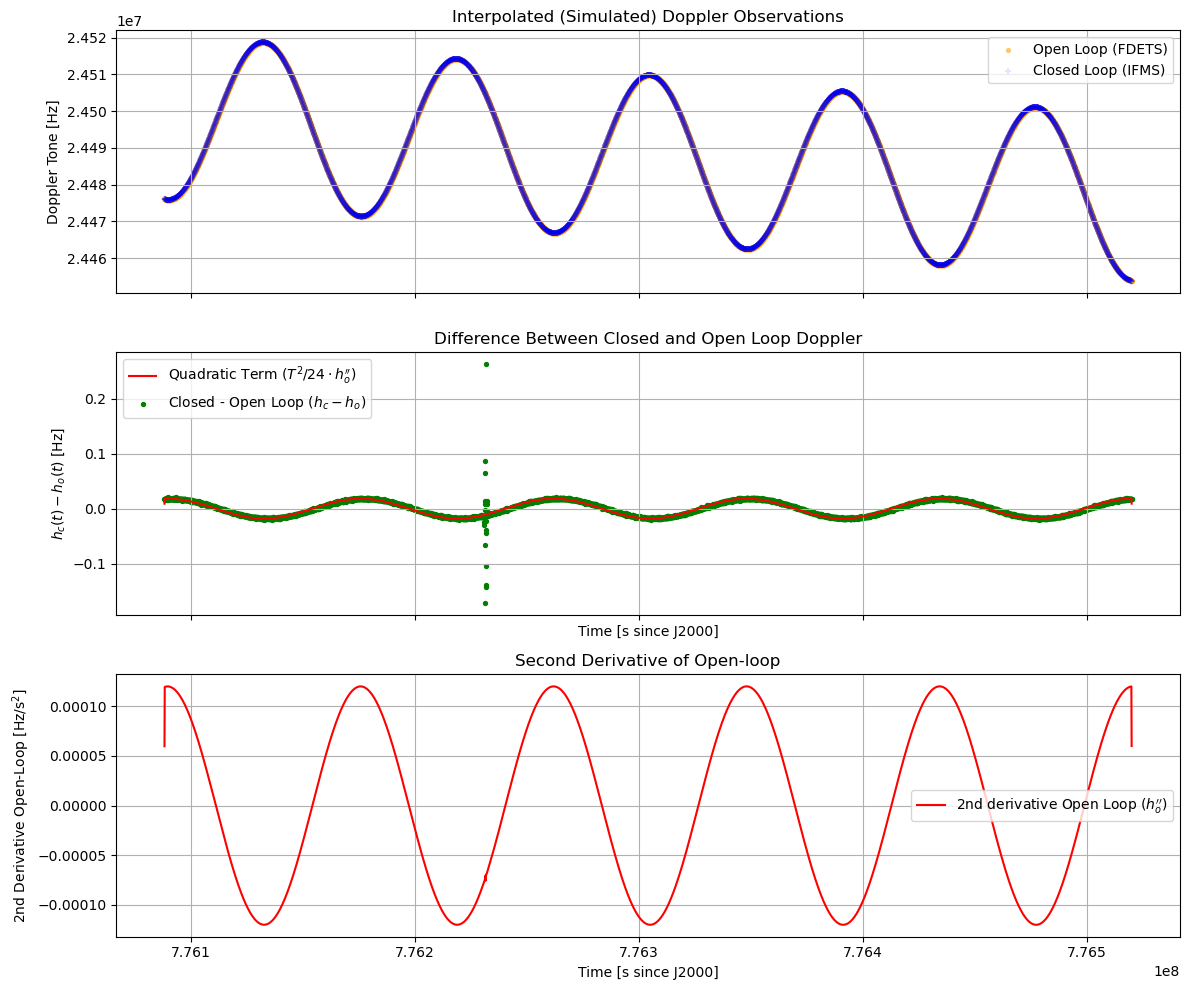

'\nSimulated FDETS Doppler shift at 2024-08-05T17:18:00:\n8436501362.975844 Hz\nSimulated FDETS Doppler shift at 2024-08-05T19:28:00:\n8436488287.565639 Hz\n'

In [12]:
####### ANOTHER VALIDATION PLOT ###########
closed_loop_interpol = interp1d(simulated_equivalent_closed_loop_times,simulated_closed_loop_tone)
cond = (times_linspace >= np.min(simulated_equivalent_closed_loop_times)) & \
       (times_linspace <= np.max(simulated_equivalent_closed_loop_times))

valid_times = times_linspace[cond]


# These are the times (midpoints) at which your closed-loop data is defined
shared_times = np.array(simulated_equivalent_closed_loop_times)

# These are the corresponding closed-loop values
closed_loop_values = simulated_closed_loop_tone

# Evaluate the INTERPOLATED open-loop function at these same midpoint times
open_loop_values = simulated_open_loop_continuous_function_utc(shared_times) - base_frequency

residual = closed_loop_values - open_loop_values

first_derivative = np.gradient(open_loop_values, shared_times)
second_derivative = np.gradient(first_derivative, shared_times)
# Define the specific UTC time you want to query
first_target_utc_string = "2024-08-05T17:18:00"
second_target_utc_string = "2024-08-05T19:28:00"
first_target_utc_datetime = datetime.strptime(first_target_utc_string, "%Y-%m-%dT%H:%M:%S")
second_target_utc_datetime = datetime.strptime(second_target_utc_string, "%Y-%m-%dT%H:%M:%S")

# Convert the Python datetime object to seconds since J2000 epoch (in TDB)
# This is the time scale used by the simulation and the interpolator
first_target_epoch_tdb = time_representation.DateTime.to_epoch(
    time_representation.DateTime.from_python_datetime(first_target_utc_datetime)
)
second_target_epoch_tdb = time_representation.DateTime.to_epoch(
    time_representation.DateTime.from_python_datetime(second_target_utc_datetime)
)

# Evaluate the continuous function (interpolator) at the target time
# Note: This assumes 'simulated_open_loop_continuous_function_utc' is defined and
# available from your previous simulation setup.
first_simulated_value_at_target = simulated_open_loop_continuous_function_utc(first_target_epoch_tdb)
second_simulated_value_at_target = simulated_open_loop_continuous_function_utc(second_target_epoch_tdb)

# The interpolator gives the raw Doppler tone; subtract the base frequency
# to get the Doppler shift, which is the standard value of interest.
doppler_shift_at_first_target = first_simulated_value_at_target #- base_frequency
doppler_shift_at_second_target = second_simulated_value_at_target #- base_frequency

print(f"Simulated FDETS Doppler shift at {first_target_utc_string}:")
print(f"{doppler_shift_at_first_target:.6f} Hz")
print(f"Simulated FDETS Doppler shift at {second_target_utc_string}:")
print(f"{doppler_shift_at_second_target:.6f} Hz")

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)


axs[0].scatter(shared_times, open_loop_values, label='Open Loop (FDETS)', color='orange', s=8, alpha = 0.5)
axs[0].scatter(shared_times, closed_loop_values, label='Closed Loop (IFMS)', color='blue', alpha = 0.1, marker = '+', s=15)
axs[0].set_title('Interpolated (Simulated) Doppler Observations')
axs[0].set_ylabel('Doppler Tone [Hz]')
axs[0].grid(True)
axs[0].legend()

# Second subplot: Residual
axs[1].plot(shared_times, second_derivative*integration_time**2/24, label="Quadratic Term ($T^2/24 \cdot h_o''$)", color='r')
axs[1].scatter(shared_times[np.abs(residual)<1000], residual[np.abs(residual)<1000], label='Closed - Open Loop ($h_c - h_o$)', color='green', s = 8)
axs[1].set_title('Difference Between Closed and Open Loop Doppler')
axs[1].set_xlabel('Time [s since J2000]')
axs[1].set_ylabel(r'$h_c(t) - h_o(t)$ [Hz]')
axs[1].grid(True)
axs[1].legend(loc='upper left')

axs[2].plot(shared_times, second_derivative, label="2nd derivative Open Loop ($h_o''$)", color='r')
axs[2].set_ylabel("2nd Derivative Open-Loop [Hz/s$^2$]")
axs[2].set_xlabel("Time [s since J2000]")
axs[2].set_title("Second Derivative of Open-loop")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

"""
Simulated FDETS Doppler shift at 2024-08-05T17:18:00:
8436501362.975844 Hz
Simulated FDETS Doppler shift at 2024-08-05T19:28:00:
8436488287.565639 Hz
"""

### Validation Plot 2: Final Comparison

This plot directly compares:
1.  **Top:** The original simulated open-loop data vs. our *equivalent* closed-loop data (from quadrature).
2.  **Middle:** The *true* simulated closed-loop data vs. our *equivalent* closed-loop data.
3.  **Bottom:** The final residuals between the *true* and *equivalent* closed-loop data. 

If the conversion is successful, the residuals in the bottom plot should be very close to zero (on the order of machine precision or numerical noise).

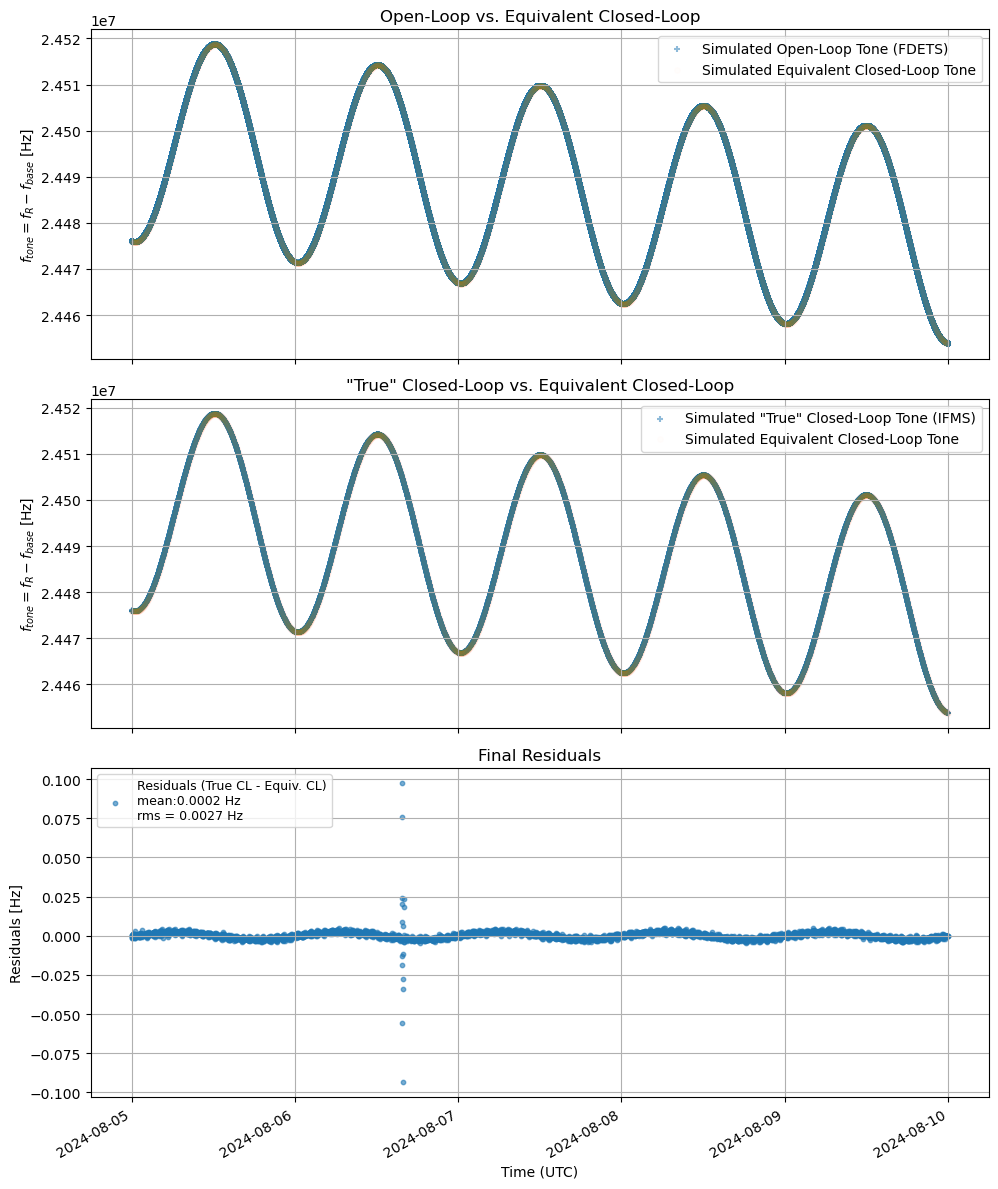

In [13]:
######################## Visualize data and residuals  ###########################
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
axs[0].scatter(simulated_times_fdets_utc, simulated_open_loop_tone, marker='+', label='Simulated Open-Loop Tone (FDETS)', s=15, alpha=0.5)
axs[0].scatter(simulated_equivalent_closed_loop_times_utc, simulated_equivalent_closed_loop_tone, marker='o', label='Simulated Equivalent Closed-Loop Tone', s=15, alpha=0.01)
axs[0].set_xlabel('Time (UTC)')
axs[0].set_ylabel('$f_{tone} = f_{R} - f_{base}$ [Hz]')
axs[0].legend()
axs[0].grid(True)
axs[0].set_title('Open-Loop vs. Equivalent Closed-Loop')

axs[1].scatter(simulated_times_ifms_utc, simulated_closed_loop_tone, marker='+', label='Simulated "True" Closed-Loop Tone (IFMS)', s=15, alpha=0.5)
axs[1].scatter(simulated_equivalent_closed_loop_times_utc, simulated_equivalent_closed_loop_tone, marker='o', label='Simulated Equivalent Closed-Loop Tone', s=15, alpha=0.01)
axs[1].set_xlabel('Time (UTC)')
axs[1].set_ylabel('$f_{tone} = f_{R} - f_{base}$ [Hz]')
axs[1].legend()
axs[1].grid(True)
axs[1].set_title('"True" Closed-Loop vs. Equivalent Closed-Loop')

filtered_difference = np.array(difference_between_closed_loops_utc)[np.abs(difference_between_closed_loops_utc) <= 0.1]
filtered_simulated_equivalent_closed_loop_times_utc = np.array(simulated_equivalent_closed_loop_times_utc)[np.abs(difference_between_closed_loops_utc) <= 0.1]

mean_filtered_difference = np.mean(filtered_difference)
rms_filtered_difference = np.std(filtered_difference)

axs[2].scatter(filtered_simulated_equivalent_closed_loop_times_utc, filtered_difference, marker='o', label = f'Residuals (True CL - Equiv. CL)\nmean:{mean_filtered_difference:.2g} Hz\nrms = {rms_filtered_difference:.2g} Hz',s=10, alpha=0.6)
axs[2].set_xlabel('Time (UTC)')
axs[2].set_ylabel('Residuals [Hz]')
axs[2].legend(loc="upper left", fontsize=9)
axs[2].grid(True)
axs[2].set_title('Final Residuals')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()
###################################################################################